In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import impute
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV

from scipy.stats import chi2_contingency

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import TomekLinks,CondensedNearestNeighbour,OneSidedSelection,NeighbourhoodCleaningRule
from imblearn.over_sampling import RandomOverSampler

from funcs import *

set_config(transform_output="pandas")
pd.set_option('future.no_silent_downcasting', True)

# Cargar Datos
Aqui dejamos adjunta la [fuente de los datos](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction).

In [2]:
url = 'https://raw.githubusercontent.com/AitzolSa/dataset/619ecb7ffa2bdfcfb5a589fb8266bcf0db15250d/archive.zip'

print("Descargando y leyendo el dataset...")
X = pd.read_csv(url, compression='zip')

print("Datos cargados con exito:")
X.head()

Descargando y leyendo el dataset...
Datos cargados con exito:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


# Dividir Train, Val y Test

In [3]:
# Dividimos train, test y validacion
semilla = 69

y = X.fraudulent
X_features = X.drop('fraudulent', axis=1)
X_resto, X_test, y_resto, y_test = model_selection.train_test_split(
    X_features, y, random_state=semilla, stratify=y, test_size=0.1
)
X_train, X_val, y_train, y_val = model_selection.train_test_split(
    X_resto, y_resto, random_state=semilla, stratify=y_resto, test_size=0.2
)

print("Train:")
print(X_train.describe())
print()

print("Val:")
print(X_val.describe())
print()

print("Test:")
print(X_test.describe())

Train:
             job_id  telecommuting  has_company_logo  has_questions
count  12873.000000   12873.000000      12873.000000   12873.000000
mean    8919.432533       0.042880          0.796784       0.492737
std     5167.644356       0.202595          0.402408       0.499967
min        2.000000       0.000000          0.000000       0.000000
25%     4408.000000       0.000000          1.000000       0.000000
50%     8935.000000       0.000000          1.000000       0.000000
75%    13380.000000       0.000000          1.000000       1.000000
max    17880.000000       1.000000          1.000000       1.000000

Val:
             job_id  telecommuting  has_company_logo  has_questions
count   3219.000000    3219.000000       3219.000000    3219.000000
mean    8991.802423       0.042249          0.788444       0.483691
std     5157.263804       0.201188          0.408475       0.499812
min        1.000000       0.000000          0.000000       0.000000
25%     4594.500000       0.000000 

# Modelo Base

Empezando train
Empezando a predecir
Resultado: 0.84276356927219


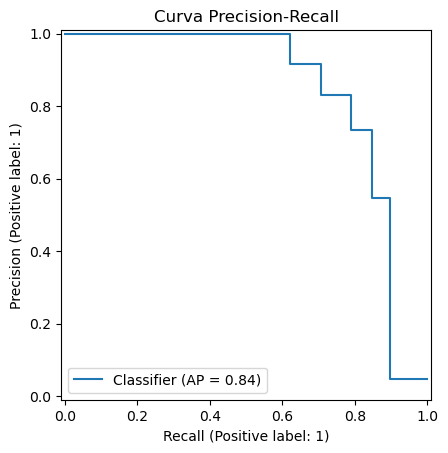

In [4]:
col_id = ["job_id"]

columnas_texto_mejor = [
    "company_profile",
    "description",
    "benefits"
]

cols_base_categoricas = [
    "title",
    "location",
    "department",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

cols_numericas = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

col_salario = ["salary_range"]

# Columnas categóricas que se usan en esta prueba
cols_categoricas_prueba = cols_base_categoricas + columnas_texto_mejor

# Número total de variables que entran antes del selector
n_variables_total = len(cols_categoricas_prueba) + len(cols_numericas)

transformer = ColumnTransformer(transformers=[
    ("imputar_categoricas",
        impute.SimpleImputer(strategy="constant", fill_value="unk"),
        cols_categoricas_prueba),

    ("imputar_salario",
        discretizador_salario(),
        col_salario),

    ("imputar_numericas",
        impute.SimpleImputer(strategy="constant", fill_value=-1),
        cols_numericas),

    ("dropear_id",
        "drop",
        col_id)
],
    remainder="drop",
    verbose_feature_names_out=False
)


numerizar = ColumnTransformer(transformers=[
    ("target_enc",
        preprocessing.TargetEncoder(smooth="auto", random_state=semilla),
        cols_categoricas_prueba + col_salario),

    ("scaler_numericas",
        preprocessing.StandardScaler(),
        cols_numericas)
],
    remainder="drop",
    verbose_feature_names_out=False
)

pipe_base = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("rellenar", transformer),
    ("numerizar_y_escalar", numerizar),
    ("seleccion_variables", SelectorCorrelacion(k=9)),
    ("knn", KNeighborsClassifier())
])

print("Empezando train")
pipe_base.fit(X_train, y_train)

print("Empezando a predecir")
preds_base = pipe_base.predict_proba(X_val)[:, 1]

pr_auc_base = metrics.average_precision_score(
    y_val,
    preds_base
)

print("Resultado: {}".format(pr_auc_base))

metrics.PrecisionRecallDisplay.from_predictions(
    y_val,
    preds_base
)

plt.title("Curva Precision-Recall")
plt.show()

pr_aucs = np.empty(5)
pr_aucs[0] = pr_auc_base

# 4. Seleccion De Instancias

## Under-Sampling

### CNN

Empezando train
Empezando a predecir
Resultado: 0.8077226891262758


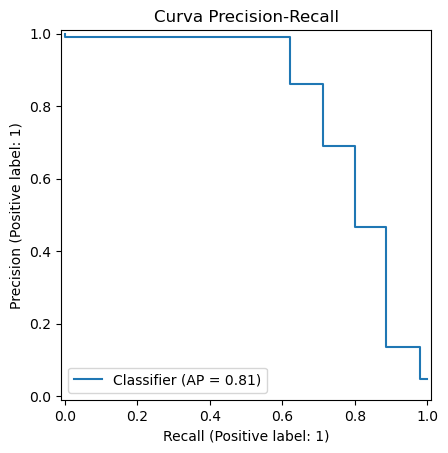

In [5]:
pipe1 = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("rellenar", transformer),
    ("numerizar_y_escalar", numerizar),
    ("seleccion_variables", SelectorCorrelacion(k=9)),
    ("limpieza_ruido",CondensedNearestNeighbour()),
    ("knn", KNeighborsClassifier())
])


print("Empezando train")
pipe1.fit(X_train, y_train)

print("Empezando a predecir")
preds_1 = pipe1.predict_proba(X_val)[:, 1]

pr_auc_1 = metrics.average_precision_score(
    y_val,
    preds_1
)

print("Resultado: {}".format(pr_auc_1))

metrics.PrecisionRecallDisplay.from_predictions(
    y_val,
    preds_1
)

plt.title("Curva Precision-Recall")
plt.show()

pr_aucs[1] = pr_auc_1

### Tomek-Links

Empezando train
Empezando a predecir
Resultado: 0.8446502346804114


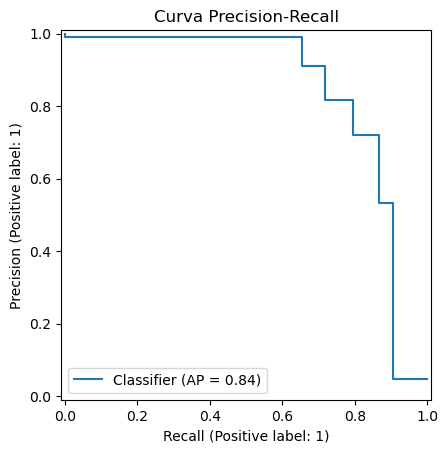

In [6]:
pipe2 = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("rellenar", transformer),
    ("numerizar_y_escalar", numerizar),
    ("seleccion_variables", SelectorCorrelacion(k=9)),
    ("limpieza_ruido",TomekLinks()),
    ("knn", KNeighborsClassifier())
])

print("Empezando train")
pipe2.fit(X_train, y_train)

print("Empezando a predecir")
preds_2 = pipe2.predict_proba(X_val)[:, 1]

pr_auc_2 = metrics.average_precision_score(
    y_val,
    preds_2
)

print("Resultado: {}".format(pr_auc_2))

metrics.PrecisionRecallDisplay.from_predictions(
    y_val,
    preds_2
)

plt.title("Curva Precision-Recall")
plt.show()

pr_aucs[2] = pr_auc_2

### OSS (CNN + Tomek-links)

Empezando train
Empezando a predecir
Resultado: 0.8408909539128351


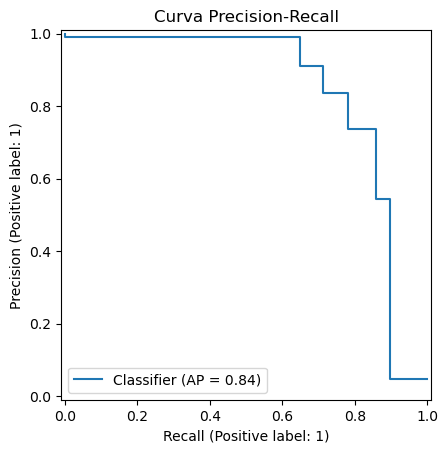

In [34]:
pipe3 = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("rellenar", transformer),
    ("numerizar_y_escalar", numerizar),
    ("seleccion_variables", SelectorCorrelacion(k=9)),
    ("limpieza_ruido",OneSidedSelection()),
    ("knn", KNeighborsClassifier())
])

print("Empezando train")
pipe3.fit(X_train, y_train)

print("Empezando a predecir")
preds_3 = pipe3.predict_proba(X_val)[:, 1]

pr_auc_3 = metrics.average_precision_score(
    y_val,
    preds_3
)

print("Resultado: {}".format(pr_auc_3))

metrics.PrecisionRecallDisplay.from_predictions(
    y_val,
    preds_3
)

plt.title("Curva Precision-Recall")
plt.show()

pr_aucs[3] = pr_auc_3

### Neighbourhood cleaning rule (NCL)

Empezando train
Empezando a predecir
Resultado: 0.7778995494749974


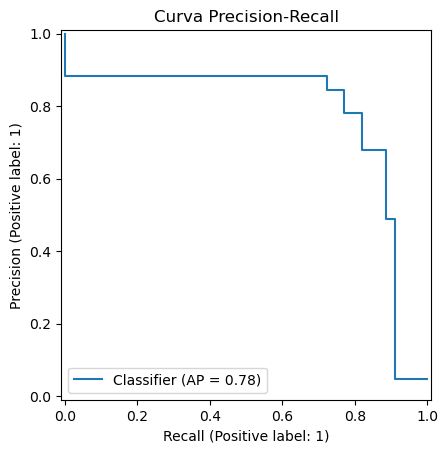

In [8]:
pipe4 = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("rellenar", transformer),
    ("numerizar_y_escalar", numerizar),
    ("seleccion_variables", SelectorCorrelacion(k=9)),
    ("limpieza_ruido",NeighbourhoodCleaningRule()),
    ("knn", KNeighborsClassifier())
])

print("Empezando train")
pipe4.fit(X_train, y_train)

print("Empezando a predecir")
preds_4 = pipe4.predict_proba(X_val)[:, 1]

pr_auc_4 = metrics.average_precision_score(
    y_val,
    preds_4
)

print("Resultado: {}".format(pr_auc_4))

metrics.PrecisionRecallDisplay.from_predictions(
    y_val,
    preds_4
)

plt.title("Curva Precision-Recall")
plt.show()

pr_aucs[4] = pr_auc_4

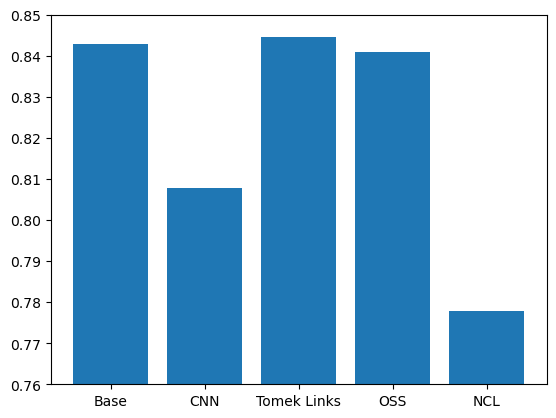

In [35]:
clases = ["Base","CNN","Tomek Links", "OSS","NCL"]

plt.bar(clases,pr_aucs)
plt.ylim(0.76,0.85)

plt.show()

### Busqueda de N Vecinos Óptimo

In [24]:
neighbors = [1,3,5,7,9]

mejores_resultados = np.empty(5)
mejores_n_neighbors = np.empty(5)

mejores_resultados[0] = pr_aucs[0]
mejores_resultados[2] = pr_aucs[2]

mejores_n_neighbors[0] = -1
mejores_n_neighbors[2] = -1

#### CNN

Empezando train n_neighburs = 1
Empezando a predecir
Resultado para n_neighbors = 1: 0.8066230496262088

Empezando train n_neighburs = 3
Empezando a predecir
Resultado para n_neighbors = 3: 0.8119053483608207

Empezando train n_neighburs = 5
Empezando a predecir
Resultado para n_neighbors = 5: 0.8075003311263373

Empezando train n_neighburs = 7
Empezando a predecir
Resultado para n_neighbors = 7: 0.7199448101365149

Empezando train n_neighburs = 9
Empezando a predecir
Resultado para n_neighbors = 9: 0.7258089346120692



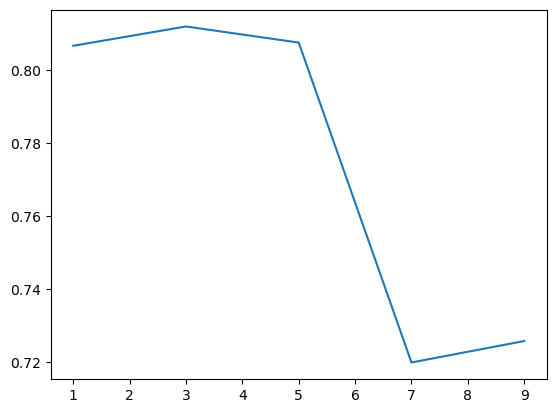

In [25]:
aux = np.empty(len(neighbors))

for i,n_neighbors in enumerate(neighbors):

    pipe = Pipeline([
        ("limpiaEspacios", limpiar_espacios()),
        ("minusculizar", minusculizar()),
        ("quitarSimbolos", quitar_simbolos()),
        ("quitarTildes", quitar_tildes()),
        ("rellenar", transformer),
        ("numerizar_y_escalar", numerizar),
        ("seleccion_variables", SelectorCorrelacion(k=9)),
        ("limpieza_ruido",CondensedNearestNeighbour(n_neighbors = n_neighbors)),
        ("knn", KNeighborsClassifier())
    ])
    
    print("Empezando train n_neighburs = {}".format(n_neighbors))
    pipe.fit(X_train, y_train)
    
    print("Empezando a predecir")
    preds = pipe.predict_proba(X_val)[:, 1]
    
    pr_auc = metrics.average_precision_score(
        y_val,
        preds
    )
    
    print("Resultado para n_neighbors = {}: {}".format(n_neighbors, pr_auc))
    print()
    
    aux[i] = pr_auc

plt.plot(neighbors,aux)

mejores_resultados[1] = aux.max()
mejores_n_neighbors[1] = neighbors[aux.argmax()]

#### OSS

Empezando train n_neighburs = 1
Empezando a predecir
Resultado para n_neighbors = 1: 0.8414184094801924

Empezando train n_neighburs = 3
Empezando a predecir
Resultado para n_neighbors = 3: 0.8413372009110642

Empezando train n_neighburs = 5
Empezando a predecir
Resultado para n_neighbors = 5: 0.8408097453437069

Empezando train n_neighburs = 7
Empezando a predecir
Resultado para n_neighbors = 7: 0.8413372009110642

Empezando train n_neighburs = 9
Empezando a predecir
Resultado para n_neighbors = 9: 0.8413372009110642



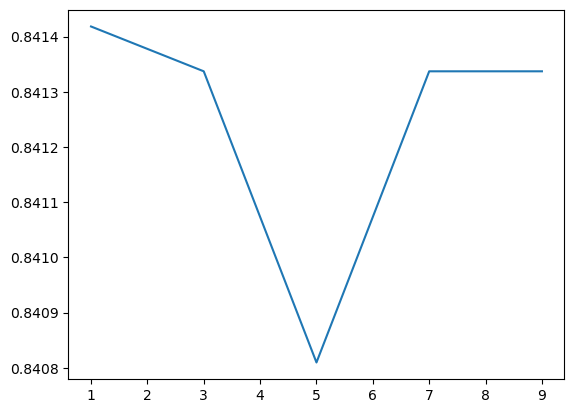

In [33]:
aux = np.empty(len(neighbors))

for i,n_neighbors in enumerate(neighbors):

    pipe = Pipeline([
        ("limpiaEspacios", limpiar_espacios()),
        ("minusculizar", minusculizar()),
        ("quitarSimbolos", quitar_simbolos()),
        ("quitarTildes", quitar_tildes()),
        ("rellenar", transformer),
        ("numerizar_y_escalar", numerizar),
        ("seleccion_variables", SelectorCorrelacion(k=9)),
        ("limpieza_ruido",OneSidedSelection(n_neighbors = n_neighbors)),
        ("knn", KNeighborsClassifier())
    ])
    
    print("Empezando train n_neighburs = {}".format(n_neighbors))
    pipe.fit(X_train, y_train)
    
    print("Empezando a predecir")
    preds = pipe.predict_proba(X_val)[:, 1]
    
    pr_auc = metrics.average_precision_score(
        y_val,
        preds
    )
    
    print("Resultado para n_neighbors = {}: {}".format(n_neighbors, pr_auc))
    print()
    
    aux[i] = pr_auc

plt.plot(neighbors,aux)

mejores_resultados[3] = aux.max()
mejores_n_neighbors[3] = neighbors[aux.argmax()]

#### NCL

Empezando train n_neighburs = 1
Empezando a predecir
Resultado para n_neighbors = 1: 0.7976868646866146

Empezando train n_neighburs = 3
Empezando a predecir
Resultado para n_neighbors = 3: 0.7778995494749974

Empezando train n_neighburs = 5
Empezando a predecir
Resultado para n_neighbors = 5: 0.7728226497207377

Empezando train n_neighburs = 7
Empezando a predecir
Resultado para n_neighbors = 7: 0.7484031121832637

Empezando train n_neighburs = 9
Empezando a predecir
Resultado para n_neighbors = 9: 0.7377062264951305



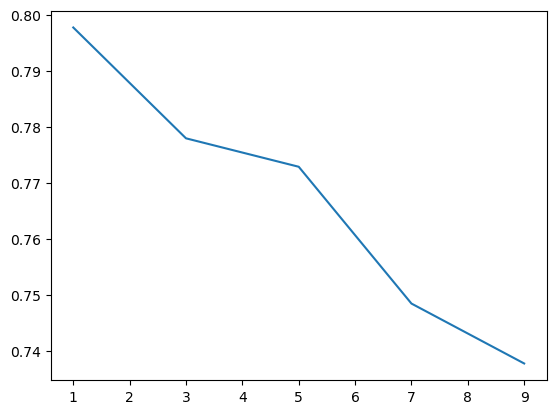

In [27]:
aux = np.empty(len(neighbors))

for i,n_neighbors in enumerate(neighbors):

    pipe = Pipeline([
        ("limpiaEspacios", limpiar_espacios()),
        ("minusculizar", minusculizar()),
        ("quitarSimbolos", quitar_simbolos()),
        ("quitarTildes", quitar_tildes()),
        ("rellenar", transformer),
        ("numerizar_y_escalar", numerizar),
        ("seleccion_variables", SelectorCorrelacion(k=9)),
        ("limpieza_ruido",NeighbourhoodCleaningRule(n_neighbors = n_neighbors)),
        ("knn", KNeighborsClassifier())
    ])
    
    print("Empezando train n_neighburs = {}".format(n_neighbors))
    pipe.fit(X_train, y_train)
    
    print("Empezando a predecir")
    preds = pipe.predict_proba(X_val)[:, 1]
    
    pr_auc = metrics.average_precision_score(
        y_val,
        preds
    )
    
    print("Resultado para n_neighbors = {}: {}".format(n_neighbors, pr_auc))
    print()
    
    aux[i] = pr_auc

plt.plot(neighbors,aux)

mejores_resultados[4] = aux.max()
mejores_n_neighbors[4] = neighbors[aux.argmax()]

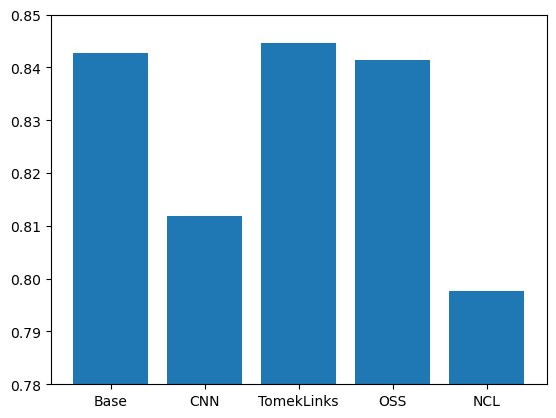

In [28]:
clases = ["Base","CNN","TomekLinks","OSS","NCL"]

plt.bar(clases,mejores_resultados)
plt.ylim(0.78,0.85)

plt.show()

(0.0, 4.0)

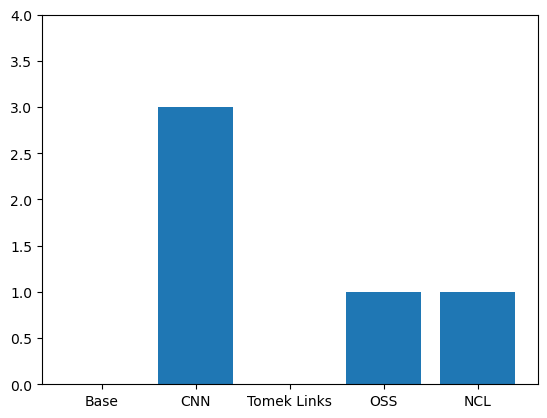

In [36]:
plt.bar(clases,mejores_n_neighbors)
plt.ylim(0,4)

## Over-sampling

Empezando train
Empezando a predecir
Resultado: 0.690924743725896


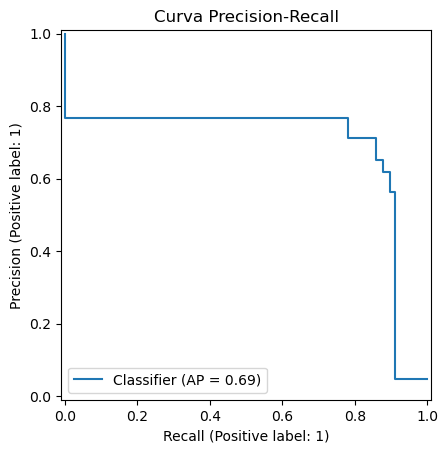

In [30]:
pipe_over = Pipeline([("transformer", transformer),
                  ("numerizar", numerizar),
                  ("selector", SelectorCorrelacion(k=10)),
                  ("over samplear",RandomOverSampler(sampling_strategy = "not majority", random_state = semilla)),
                  ("knn", KNeighborsClassifier())])

print("Empezando train")
pipe_over.fit(X_train, y_train)

print("Empezando a predecir")
preds_over = pipe_over.predict_proba(X_val)[:, 1]

pr_auc_over = metrics.average_precision_score(
    y_val,
    preds_over
)

print("Resultado: {}".format(pr_auc_over))

metrics.PrecisionRecallDisplay.from_predictions(
    y_val,
    preds_over
)

plt.title("Curva Precision-Recall")
plt.show()